**Estructura del notebook:**
1. Carga y preparacion de datos
2. Tratamiento del desequilibrio de clases (SMOTE y pesos)
3. Modelos supervisados: Regresion Logistica, Arbol, Random Forest, Gradient Boosting
4. Evaluacion comparada: metricas, curvas ROC, umbral optimo
5. Importancia de variables
6. Modelos no supervisados: Isolation Forest y LOF
7. Arquitectura de dos capas (no supervisado + supervisado)
8. Comparativa 10% vs 20% de invalidas
9. Tabla resumen final


## 1. Carga y preparacion de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     IsolationForest)
from sklearn.neighbors       import LocalOutlierFactor
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     GridSearchCV)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, roc_curve,
                                     confusion_matrix, classification_report,
                                     precision_recall_curve,
                                     ConfusionMatrixDisplay,
                                     f1_score, recall_score,
                                     precision_score)
from sklearn.metrics import balanced_accuracy_score
from imblearn.over_sampling  import SMOTE
from scipy.stats             import gaussian_kde

np.random.seed(2024)
plt.rcParams.update({'figure.dpi':110,'axes.titlesize':11,
                     'axes.labelsize':10,'legend.fontsize':9,
                     'font.family':'serif'})

#Carga de datasets
df_10 = pd.read_csv('dataset_ILP_CyL_10pct.csv', index_col='firma_id')
df_20 = pd.read_csv('dataset_ILP_CyL_20pct.csv', index_col='firma_id')

VARS = [f'x{i}' for i in range(1, 14)]
META = ['provincia','municipio','pliego','fedatario']

X10 = df_10[VARS].values;  y10 = df_10['y'].values
X20 = df_20[VARS].values;  y20 = df_20['y'].values

print("Dataset 10% -", X10.shape, "| Invalidas:", y10.sum(),
      f"({y10.mean():.1%})")
print("Dataset 20% -", X20.shape, "| Invalidas:", y20.sum(),
      f"({y20.mean():.1%})")


Dataset 10% - (50000, 13) | Invalidas: 5000 (10.0%)
Dataset 20% - (50000, 13) | Invalidas: 10000 (20.0%)


## 2. Tratamiento del desequilibrio de clases

Distribucion original 10%  : [45000  5000]
Distribucion tras SMOTE    : [45000 45000]
Peso asignado clase invalida: 9.0


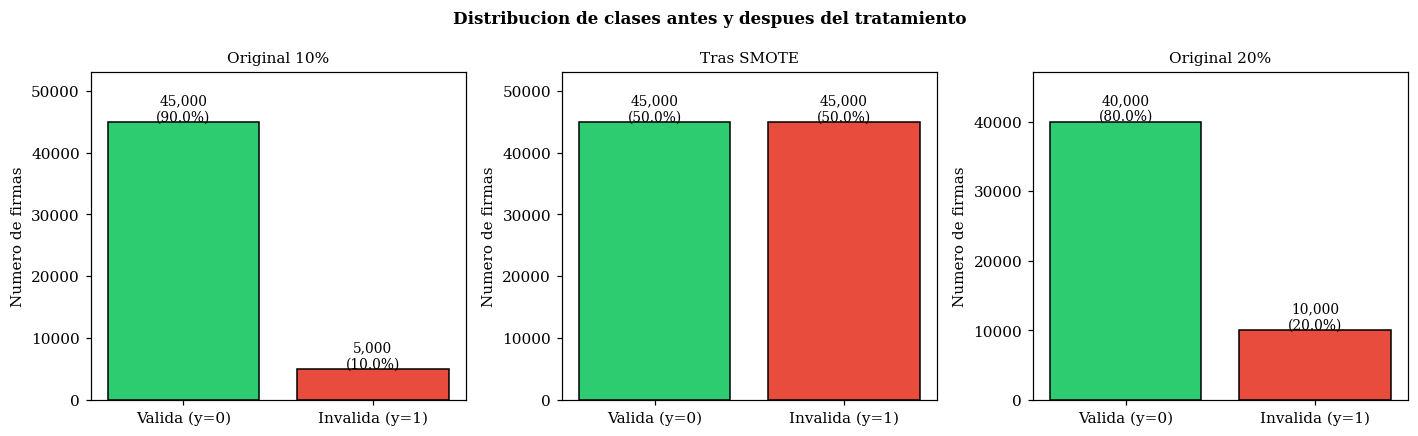

In [2]:
#SMOTE sobre dataset 10%
smote = SMOTE(random_state=2024, k_neighbors=5)
X10_sm, y10_sm = smote.fit_resample(X10, y10)

#Pesos de clase
ratio_10 = (y10 == 0).sum() / (y10 == 1).sum()
class_weights_10 = {0: 1.0, 1: ratio_10}

print("Distribucion original 10%  :", np.bincount(y10))
print("Distribucion tras SMOTE    :", np.bincount(y10_sm))
print(f"Peso asignado clase invalida: {ratio_10:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (y_s, titulo) in zip(axes, [
        (y10,    'Original 10%'),
        (y10_sm, 'Tras SMOTE'),
        (y20,    'Original 20%')]):
    counts = np.bincount(y_s)
    bars = ax.bar(['Valida (y=0)','Invalida (y=1)'], counts,
                  color=['#2ecc71','#e74c3c'], edgecolor='black')
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel('Numero de firmas')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+200,
                f'{c:,}\n({c/len(y_s):.1%})',
                ha='center', fontsize=9)
    ax.set_ylim(0, max(counts)*1.18)
plt.suptitle('Distribucion de clases antes y despues del tratamiento',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


## 3. Framework de evaluacion

In [18]:
def evaluar_modelo_asimetrico(nombre, modelo, X, y, cv=5, c_fp=3.0, c_fn=1.0):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=2024)
    aucs, sens, esps, f1s, precs = [], [], [], [], []
    fprs_all, tprs_all = [], []
    cms = []
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        # Clonar modelo para no mezclar estados
        from sklearn.base import clone
        modelo_clon = clone(modelo)
        modelo_clon.fit(X_tr, y_tr)
        y_prob_tr = modelo_clon.predict_proba(X_tr)[:,1]
        tau = umbral_optimo_asimetrico(
            y_tr,
            y_prob_tr,
            c_fp,
            c_fn
        )
        y_prob = modelo_clon.predict_proba(X_te)[:, 1]
        y_pred = (y_prob >= tau).astype(int)
        # Métricas
        aucs.append(roc_auc_score(y_te, y_prob))
        sens.append(recall_score(y_te, y_pred, zero_division=0))
        esps.append(recall_score(y_te, y_pred, pos_label=0, zero_division=0))
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        cms.append(confusion_matrix(y_te, y_pred))
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        fprs_all.append(fpr); tprs_all.append(tpr)
    cm_media = np.mean(cms, axis=0).astype(int)
    return {
        'nombre': nombre,
        'AUC': np.mean(aucs), 'AUC_std': np.std(aucs),
        'Sens': np.mean(sens), 'Sens_std': np.std(sens),
        'Esp': np.mean(esps), 'Esp_std': np.std(esps),
        'F1': np.mean(f1s), 'F1_std': np.std(f1s),
        'Prec': np.mean(precs), 'Prec_std': np.std(precs),
        'CM': cm_media,
        'fprs': fprs_all, 'tprs': tprs_all
    }

def umbral_optimo_asimetrico(y_true, y_prob,
                             c_fp=3.0, c_fn=1.0,
                             n_thresholds=50):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    losses = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        fp = cm[0,1]
        fn = cm[1,0]
        losses.append(c_fp*fp + c_fn*fn)
    return thresholds[np.argmin(losses)]

print("Framework de evaluacion definido.")
print("  - evaluar_modelo(): CV estratificada 5 pliegues")
print("  - umbral_optimo_asimetrico(): minimiza c_FP·FP + c_FN·FN")


Framework de evaluacion definido.
  - evaluar_modelo(): CV estratificada 5 pliegues
  - umbral_optimo_asimetrico(): minimiza c_FP·FP + c_FN·FN


## 4. Modelos supervisados

### 4.1 Definicion y entrenamiento de los cuatro modelos

In [19]:
#Definicion de modelos
scaler = StandardScaler()

modelos = {
    'Reg. Logistica': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, class_weight=class_weights_10,
                                   max_iter=1000, random_state=2024))
    ]),
    'Arbol Decision': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=30,
        class_weight=class_weights_10, random_state=2024
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_features='sqrt',
        class_weight=class_weights_10, n_jobs=-1, random_state=2024
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05,
        max_depth=4, random_state=2024
    )
}

#Evaluacion con CV estratificada
print("\nEvaluando modelos (CV 5 pliegues)...")
resultados = {}
for nombre, modelo in modelos.items():
    res = evaluar_modelo_asimetrico(nombre, modelo, X10, y10, cv=5)
    resultados[nombre] = res
    print(f"  {nombre:<22}: AUC={res['AUC']:.3f} | "
          f"Sens={res['Sens']:.3f} | Esp={res['Esp']:.3f} | "
          f"F1={res['F1']:.3f}")



Evaluando modelos (CV 5 pliegues)...
  Reg. Logistica        : AUC=0.960 | Sens=0.636 | Esp=0.997 | F1=0.763
  Arbol Decision        : AUC=0.928 | Sens=0.588 | Esp=1.000 | F1=0.738
  Random Forest         : AUC=0.948 | Sens=0.740 | Esp=0.988 | F1=0.802
  Gradient Boosting     : AUC=0.962 | Sens=0.676 | Esp=0.998 | F1=0.799


### 4.2 Curvas ROC y matrices de confusion

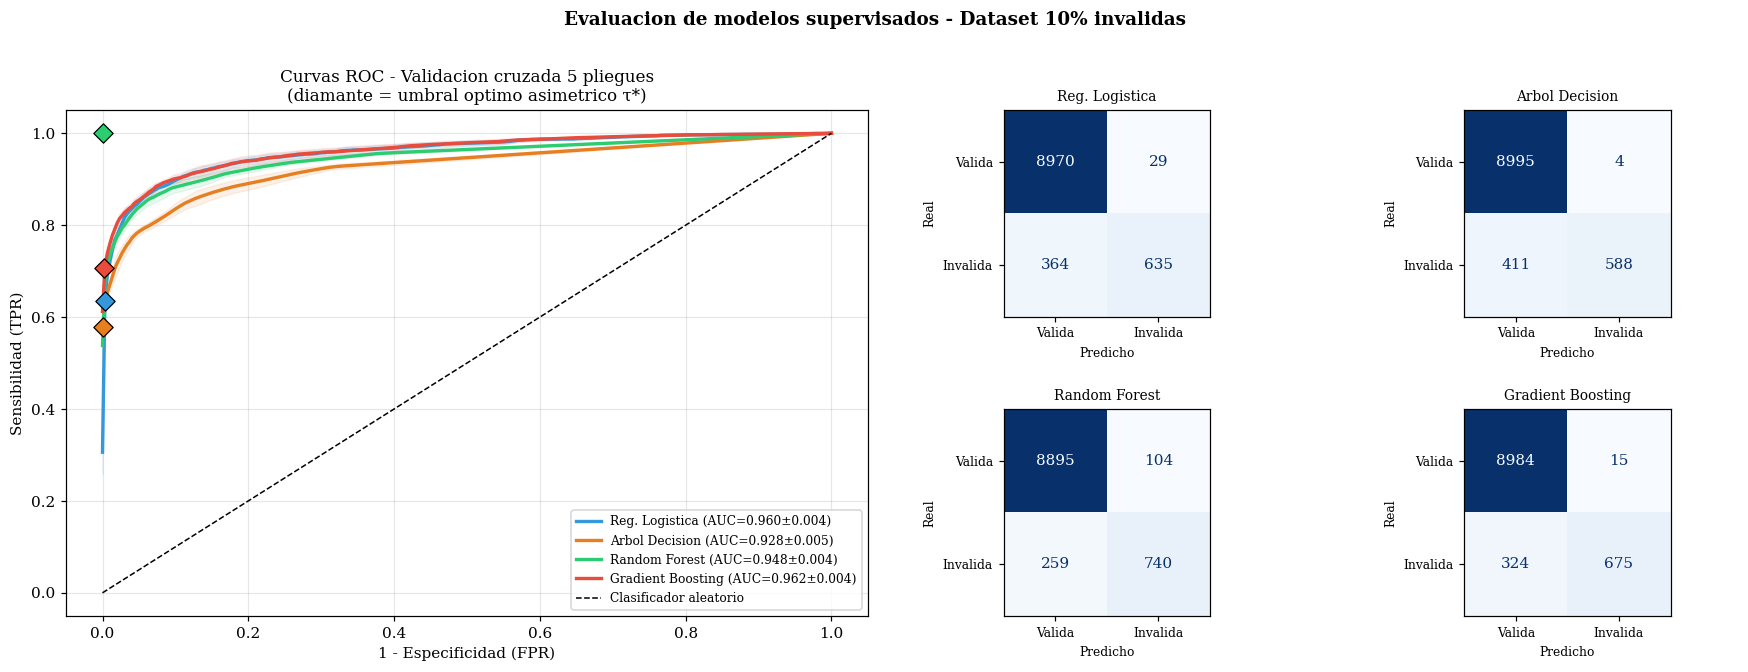

In [20]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

#PCurvas ROC
ax_roc = fig.add_subplot(gs[0, 0])
colores_mod = ['#3498db','#e67e22','#2ecc71','#e74c3c']

for (nombre, res), color in zip(resultados.items(), colores_mod):
    # Interpolar TPR sobre rejilla com_n de FPR
    mean_fpr = np.linspace(0, 1, 300)
    tprs_interp = []
    for fpr, tpr in zip(res['fprs'], res['tprs']):
        tprs_interp.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp,  axis=0)

    ax_roc.plot(mean_fpr, mean_tpr, color=color, linewidth=2.2,
                label=f"{nombre} (AUC={res['AUC']:.3f}±{res['AUC_std']:.3f})")
    ax_roc.fill_between(mean_fpr,
                        mean_tpr - std_tpr,
                        mean_tpr + std_tpr,
                        color=color, alpha=0.10)
    
    modelos[nombre].fit(X10, y10)
    y_prob_all = modelos[nombre].predict_proba(X10)[:, 1]
    fpr_t, tpr_t, thr = roc_curve(y10, y_prob_all)
    tau = umbral_optimo_asimetrico(y10, y_prob_all, c_fp=3.0, c_fn=1.0)
    idx_t = np.argmin(np.abs(thr - tau))
    ax_roc.scatter(fpr_t[idx_t], tpr_t[idx_t],
                   color=color, s=80, zorder=5,
                   marker='D', edgecolors='black', linewidths=0.8)

ax_roc.plot([0,1],[0,1],'k--', linewidth=1, label='Clasificador aleatorio')
ax_roc.set_xlabel('1 - Especificidad (FPR)')
ax_roc.set_ylabel('Sensibilidad (TPR)')
ax_roc.set_title('Curvas ROC - Validacion cruzada 5 pliegues\n'
                 '(diamante = umbral optimo asimetrico τ*)')
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.grid(True, alpha=0.3)

#Matrices de confusion
ax_cms = fig.add_subplot(gs[0, 1])
ax_cms.axis('off')

gs_cms = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0,1],
                                          hspace=0.45, wspace=0.35)
for i, (nombre, res) in enumerate(resultados.items()):
    ax_cm = fig.add_subplot(gs_cms[i//2, i%2])
    disp  = ConfusionMatrixDisplay(confusion_matrix=res['CM'],
                                   display_labels=['Valida','Invalida'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues',
              values_format='d')
    ax_cm.set_title(nombre, fontsize=9)
    ax_cm.set_xlabel('Predicho', fontsize=8)
    ax_cm.set_ylabel('Real', fontsize=8)
    ax_cm.tick_params(labelsize=8)

plt.suptitle('Evaluacion de modelos supervisados - Dataset 10% invalidas',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 4.3 Tabla comparativa de metricas

  TABLA COMPARATIVA DE MODELOS SUPERVISADOS - Dataset 10% invalidas
  Umbral tau* optimizado bajo perdida asimetrica (c_FP=3, c_FN=1)
           Modelo           AUC  Sensibilidad Especificidad            F1     Precision
   Reg. Logistica 0.960 ± 0.004 0.636 ± 0.021 0.997 ± 0.001 0.763 ± 0.015 0.956 ± 0.010
   Arbol Decision 0.928 ± 0.005 0.588 ± 0.019 1.000 ± 0.000 0.738 ± 0.014 0.993 ± 0.004
    Random Forest 0.948 ± 0.004 0.740 ± 0.023 0.988 ± 0.002 0.802 ± 0.008 0.877 ± 0.015
Gradient Boosting 0.962 ± 0.004 0.676 ± 0.011 0.998 ± 0.001 0.799 ± 0.008 0.978 ± 0.011


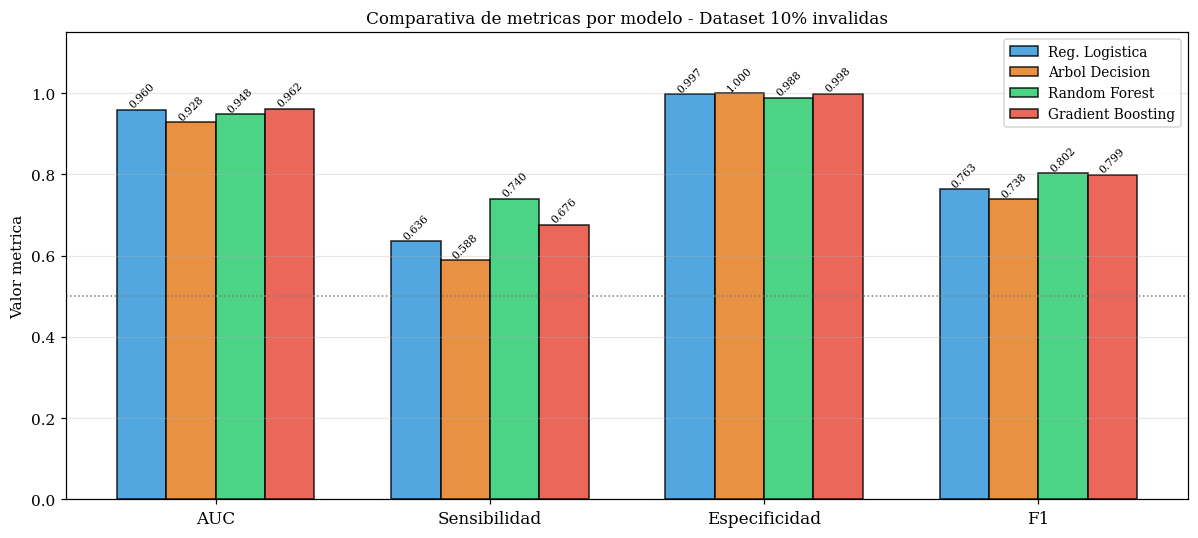

In [21]:
metricas_tabla = []
for nombre, res in resultados.items():
    metricas_tabla.append({
        'Modelo'       : nombre,
        'AUC'          : f"{res['AUC']:.3f} ± {res['AUC_std']:.3f}",
        'Sensibilidad' : f"{res['Sens']:.3f} ± {res['Sens_std']:.3f}",
        'Especificidad': f"{res['Esp']:.3f} ± {res['Esp_std']:.3f}",
        'F1'           : f"{res['F1']:.3f} ± {res['F1_std']:.3f}",
        'Precision'    : f"{res['Prec']:.3f} ± {res['Prec_std']:.3f}"
    })

df_metricas = pd.DataFrame(metricas_tabla)
print("=" * 85)
print("  TABLA COMPARATIVA DE MODELOS SUPERVISADOS - Dataset 10% invalidas")
print("  Umbral tau* optimizado bajo perdida asimetrica (c_FP=3, c_FN=1)")
print("=" * 85)
print(df_metricas.to_string(index=False))
print("=" * 85)

# Grafico de barras de m_tricas
metricas_num = {nombre: [res['AUC'], res['Sens'], res['Esp'], res['F1']]
                for nombre, res in resultados.items()}
etiq_met = ['AUC', 'Sensibilidad', 'Especificidad', 'F1']
x_pos    = np.arange(len(etiq_met))
colores_mod = ['#3498db','#e67e22','#2ecc71','#e74c3c']

fig, ax = plt.subplots(figsize=(11, 5))
n_mod = len(modelos)
ancho = 0.18
for i, (nombre, vals) in enumerate(metricas_num.items()):
    offset = (i - n_mod/2 + 0.5) * ancho
    bars = ax.bar(x_pos + offset, vals, ancho,
                  label=nombre, color=colores_mod[i],
                  edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=7, rotation=45)

ax.set_xticks(x_pos)
ax.set_xticklabels(etiq_met, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor metrica')
ax.set_title('Comparativa de metricas por modelo - Dataset 10% invalidas')
ax.legend(fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


### 4.4 Importancia de variables

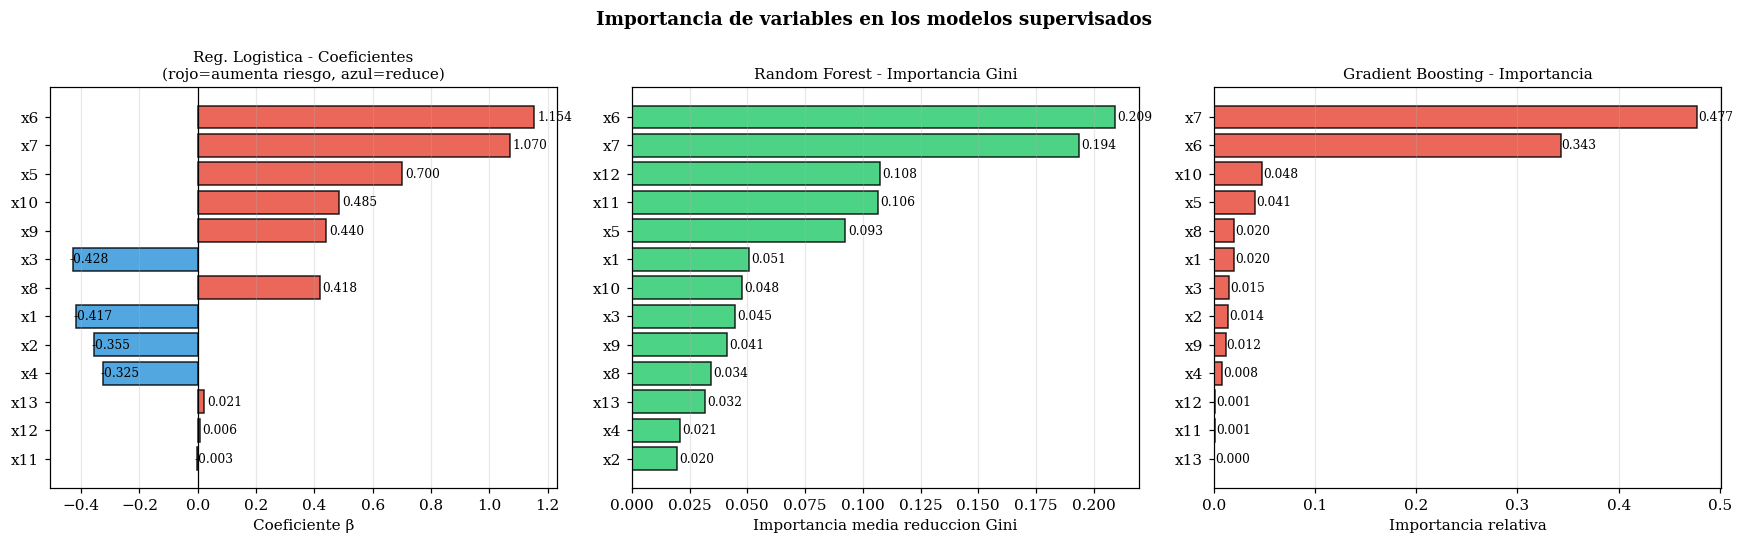

   Variable  Coef_RL   OR_RL  Imp_RF  Imp_GB
5        x6   1.1542  3.1714  0.2093  0.3426
6        x7   1.0696  2.9141  0.1936  0.4775
11      x12   0.0059  1.0059  0.1076  0.0011
10      x11  -0.0026  0.9974  0.1065  0.0010
4        x5   0.7000  2.0137  0.0925  0.0407
0        x1  -0.4166  0.6593  0.0509  0.0198
9       x10   0.4848  1.6238  0.0476  0.0477
2        x3  -0.4284  0.6516  0.0446  0.0155
8        x9   0.4398  1.5524  0.0410  0.0118
7        x8   0.4182  1.5193  0.0342  0.0205
12      x13   0.0212  1.0214  0.0318  0.0001
3        x4  -0.3254  0.7223  0.0207  0.0079
1        x2  -0.3547  0.7014  0.0196  0.0139


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Coeficientes Regresion Logistica
rl = modelos['Reg. Logistica']
rl.fit(X10, y10)
coefs = rl.named_steps['clf'].coef_[0]
odds  = np.exp(coefs)
idx_s = np.argsort(np.abs(coefs))
colores_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coefs[idx_s]]
axes[0].barh(np.array(VARS)[idx_s], coefs[idx_s],
             color=colores_coef, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Reg. Logistica - Coeficientes\n(rojo=aumenta riesgo, azul=reduce)',
                  fontsize=10)
axes[0].set_xlabel('Coeficiente β')
for i, (v, c) in enumerate(zip(coefs[idx_s], np.array(VARS)[idx_s])):
    axes[0].text(v + 0.01*np.sign(v), i, f'{v:.3f}', va='center', fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

#Importancia Random Forest
rf = modelos['Random Forest']
rf.fit(X10, y10)
imp_rf  = rf.feature_importances_
idx_rf  = np.argsort(imp_rf)
axes[1].barh(np.array(VARS)[idx_rf], imp_rf[idx_rf],
             color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].set_title('Random Forest - Importancia Gini', fontsize=10)
axes[1].set_xlabel('Importancia media reduccion Gini')
for i, v in enumerate(imp_rf[idx_rf]):
    axes[1].text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)
axes[1].grid(True, alpha=0.3, axis='x')

#Importancia Gradient Boosting
gb = modelos['Gradient Boosting']
gb.fit(X10, y10)
imp_gb = gb.feature_importances_
idx_gb = np.argsort(imp_gb)
axes[2].barh(np.array(VARS)[idx_gb], imp_gb[idx_gb],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[2].set_title('Gradient Boosting - Importancia', fontsize=10)
axes[2].set_xlabel('Importancia relativa')
for i, v in enumerate(imp_gb[idx_gb]):
    axes[2].text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Importancia de variables en los modelos supervisados',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#Tabla resumen de importancias de las variables estandardizadas
df_imp = pd.DataFrame({
    'Variable'        : VARS,
    'Coef_RL'         : np.round(coefs, 4),
    'OR_RL'           : np.round(odds, 4),
    'Imp_RF'          : np.round(imp_rf, 4),
    'Imp_GB'          : np.round(imp_gb, 4)
}).sort_values('Imp_RF', ascending=False)

print(df_imp)

## 5. Modelos no supervisados: Isolation Forest y LOF

  MODELOS NO SUPERVISADOS - Dataset 10% invalidas

  Isolation Forest
  AUC-ROC     : 0.925
  Sensibilidad: 0.651  (firmas invalidas detectadas)
  Especificidad:0.964  (firmas validas correctamente conservadas)
  F1          : 0.659

  Local Outlier Factor
  AUC-ROC     : 0.705
  Sensibilidad: 0.245  (firmas invalidas detectadas)
  Especificidad:0.912  (firmas validas correctamente conservadas)
  F1          : 0.241


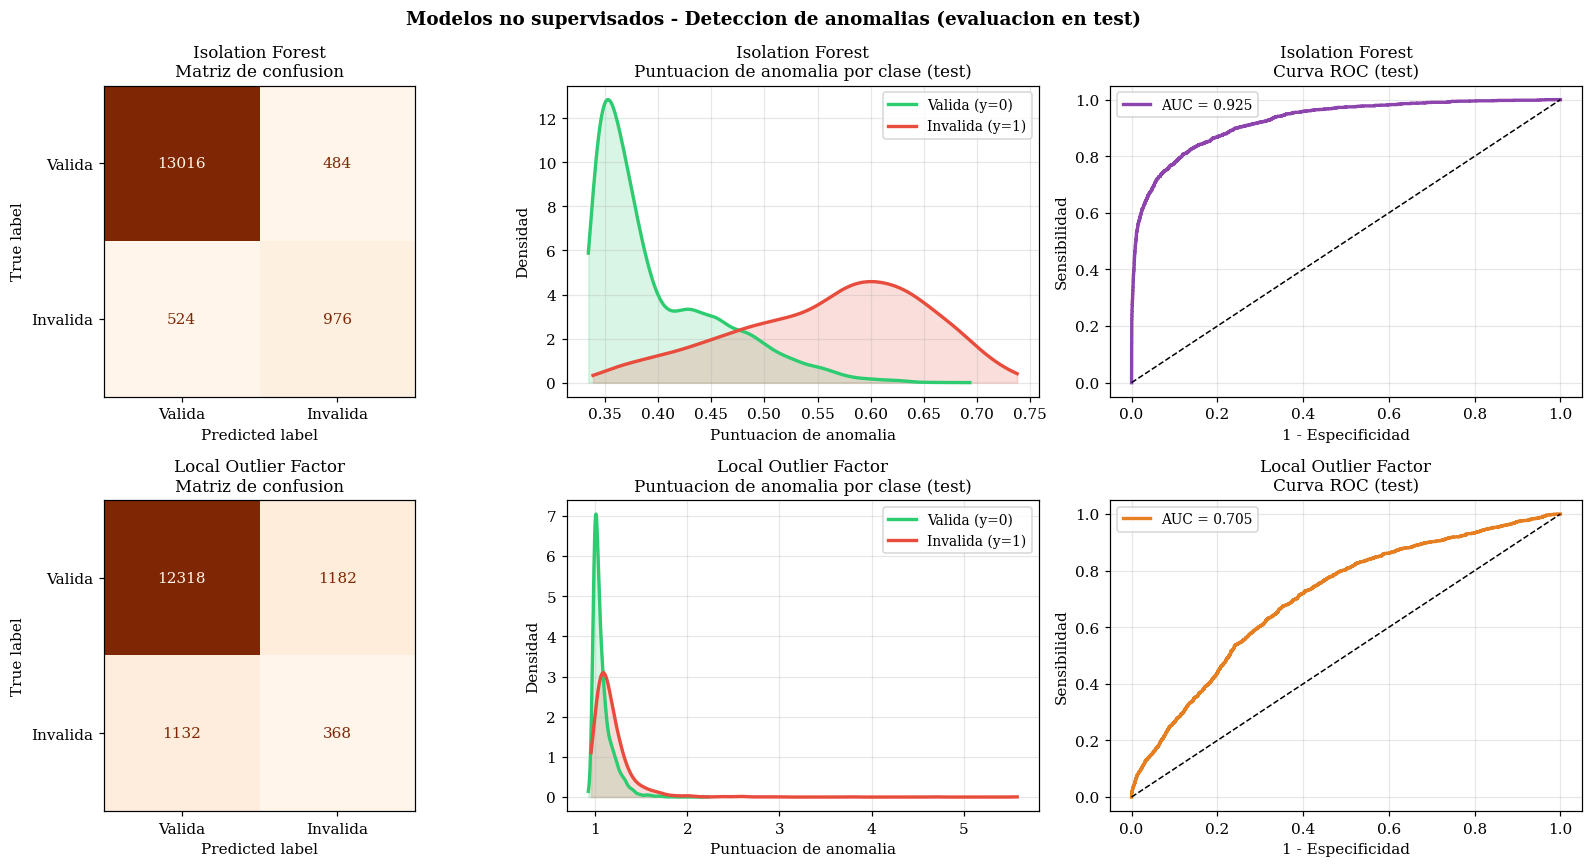

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X10, y10, test_size=0.3, random_state=2024, stratify=y10)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

#Isolation Forest
iso = IsolationForest(n_estimators=100, contamination=0.10, random_state=2024, n_jobs=-1)
#-1 = anomal, 1 = normal -> convertir a 0/1
iso.fit(X_train_sc)
y_iso_pred_test = (iso.predict(X_test_sc) == -1).astype(int)
score_iso_test = -iso.score_samples(X_test_sc)

#Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10, novelty=True)
lof.fit(X_train_sc)
y_lof_pred_test = (lof.predict(X_test_sc) == -1).astype(int)
score_lof_test = -lof.score_samples(X_test_sc)


#Metricas de deteccion
def metricas_ns(nombre, y_true, y_pred, scores):
    cm   = confusion_matrix(y_true, y_pred)
    sens = recall_score(y_true, y_pred, zero_division=0)
    esp  = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, scores)
    except:
        auc = float('nan')
    print(f"\n  {nombre}")
    print(f"  AUC-ROC     : {auc:.3f}")
    print(f"  Sensibilidad: {sens:.3f}  (firmas invalidas detectadas)")
    print(f"  Especificidad:{esp:.3f}  (firmas validas correctamente conservadas)")
    print(f"  F1          : {f1:.3f}")
    return {'nombre':nombre,'AUC':auc,'Sens':sens,'Esp':esp,'F1':f1,
            'CM':cm,'scores':scores}

print("=" * 55)
print("  MODELOS NO SUPERVISADOS - Dataset 10% invalidas")
print("=" * 55)
res_iso = metricas_ns('Isolation Forest', y_test, y_iso_pred_test, score_iso_test)
res_lof = metricas_ns('Local Outlier Factor', y_test, y_lof_pred_test, score_lof_test)

#Visualizacion
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (res, nombre_c) in enumerate([
        (res_iso,'Isolation Forest'),
        (res_lof,'Local Outlier Factor')]):

    # Matriz de confusi_n
    ConfusionMatrixDisplay(confusion_matrix=res['CM'],
                           display_labels=['Valida','Invalida']
                           ).plot(ax=axes[row,0], colorbar=False, cmap='Oranges')
    axes[row,0].set_title(f'{nombre_c}\nMatriz de confusion')

    # Distribuci_n de puntuaci_n de anomal_a por clase
    for clase, color, lbl in [(0,'#2ecc71','Valida (y=0)'),
                               (1,'#e74c3c','Invalida (y=1)')]:
        datos = res['scores'][y_test == clase]
        datos = res['scores'][y_test == clase]   # ← importante: y_test
        if len(datos) > 1:
            kde = gaussian_kde(datos, bw_method='scott')
            x_rng = np.linspace(datos.min(), datos.max(), 300)
            axes[row,1].plot(x_rng, kde(x_rng), linewidth=2.2, color=color, label=lbl)
            axes[row,1].fill_between(x_rng, kde(x_rng), alpha=0.18, color=color)
    axes[row,1].set_title(f'{nombre_c}\nPuntuacion de anomalia por clase (test)')
    axes[row,1].set_xlabel('Puntuacion de anomalia')
    axes[row,1].set_ylabel('Densidad')
    axes[row,1].legend()
    axes[row,1].grid(True, alpha=0.3)

    # Curva ROC (con puntuaciones de test y etiquetas de test)
    fpr, tpr, _ = roc_curve(y_test, res['scores'])
    axes[row,2].plot(fpr, tpr, linewidth=2.2,
                     color='#8e44ad' if row==0 else '#e67e22',
                     label=f"AUC = {res['AUC']:.3f}")
    axes[row,2].plot([0,1], [0,1], 'k--', linewidth=1)
    axes[row,2].set_title(f'{nombre_c}\nCurva ROC (test)')
    axes[row,2].set_xlabel('1 - Especificidad')
    axes[row,2].set_ylabel('Sensibilidad')
    axes[row,2].legend()
    axes[row,2].grid(True, alpha=0.3)

plt.suptitle('Modelos no supervisados - Deteccion de anomalias (evaluacion en test)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Arquitectura de dos capas

  ARQUITECTURA DE DOS CAPAS
  Firmas totales                    : 15,000
  Sospechosas por IF                : 1,460 (9.7%)
  Sospechosas por LOF               : 1,550 (10.3%)
  Sospechosas (IF OR LOF)           : 2,627 (17.5%)
  Sospechosas (IF AND LOF)          : 383 (2.6%)

  De las firmas invalidas reales:
  Capturadas por IF OR LOF          : 1087 / 1500 ((72.5% recall capa 1)

  Subconjunto para capa 2          : 2,627 firmas
  Invalidas en subconjunto         : 1,087 (41.4%)

  Random Forest sobre sospechosas:
  AUC=0.972 | Sens=0.903 | Esp=0.920 | F1=0.896

  Resumen de eficiencia:
  Recall capa 1 (cobertura invalidas): 72.5%
  Reduccion de carga de revision     : 82.5%
  -> El sistema concentra la revision manual en el 17.5% de las firmas,
    cubriendo el 72.5% de todas las irregularidades.


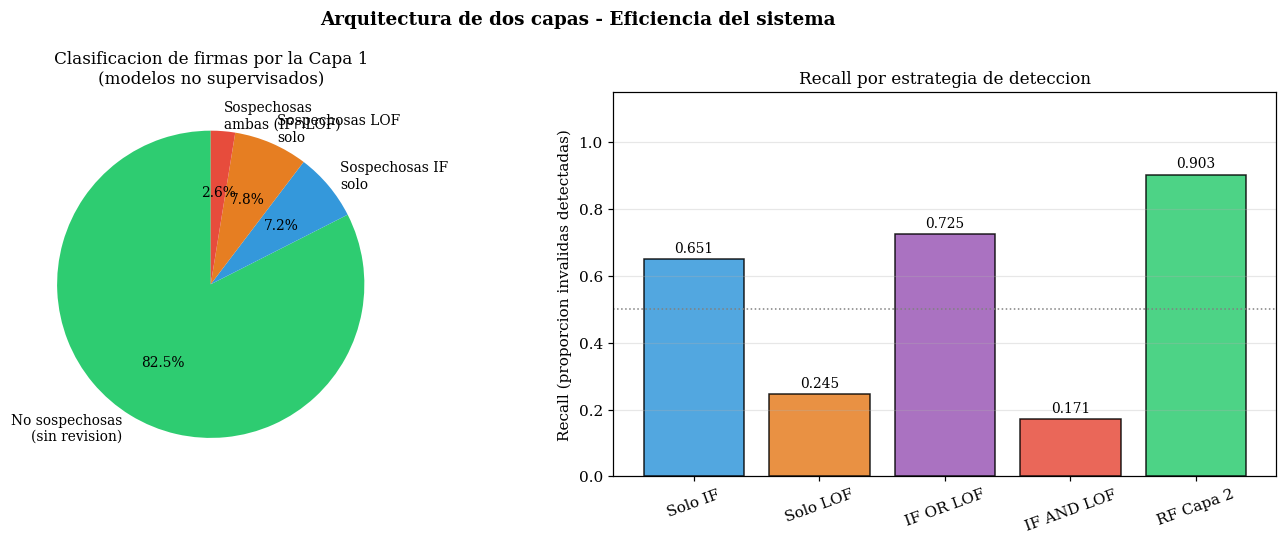

In [25]:
#Primera capa: filtrado no supervisado
# Marcamos como sospechosas las firmas detectadas por IF O LOF
sospechosas_iso = y_iso_pred_test == 1
sospechosas_lof = y_lof_pred_test == 1
sospechosas_union = sospechosas_iso | sospechosas_lof
sospechosas_inter = sospechosas_iso & sospechosas_lof

print("=" * 60)
print("  ARQUITECTURA DE DOS CAPAS")
print("=" * 60)
print(f"  Firmas totales                    : {len(y_test):,}")
print(f"  Sospechosas por IF                : {sospechosas_iso.sum():,} "
      f"({sospechosas_iso.mean():.1%})")
print(f"  Sospechosas por LOF               : {sospechosas_lof.sum():,} "
      f"({sospechosas_lof.mean():.1%})")
print(f"  Sospechosas (IF OR LOF)           : {sospechosas_union.sum():,} "
      f"({sospechosas_union.mean():.1%})")
print(f"  Sospechosas (IF AND LOF)          : {sospechosas_inter.sum():,} "
      f"({sospechosas_inter.mean():.1%})")
print()
print("  De las firmas invalidas reales:")
recall_capa1 = (
    (sospechosas_union & (y_test==1)).sum()
    / (y_test==1).sum()
)
print(f"  Capturadas por IF OR LOF          : "
      f"{(sospechosas_union & (y_test==1)).sum()} / {(y_test==1).sum()} "
      f"(({recall_capa1*100:.1f}% recall capa 1)")

#Segunda capa: Random Forest sobre el subconjunto sospechoso
X_sosp = X_test[sospechosas_union]
y_sosp = y_test[sospechosas_union]

print(f"\n  Subconjunto para capa 2          : {len(y_sosp):,} firmas")
print(f"  Invalidas en subconjunto         : {y_sosp.sum():,} "
      f"({y_sosp.mean():.1%})")

# Evaluar RF en el subconjunto sospechoso
if y_sosp.sum() > 10 and (y_sosp==0).sum() > 10:
    rf_capa2 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       n_jobs=-1, random_state=2024)
    res_capa2 = evaluar_modelo_asimetrico('RF - Capa 2', rf_capa2,
                                X_sosp, y_sosp, cv=5)
    print(f"\n  Random Forest sobre sospechosas:")
    print(f"  AUC={res_capa2['AUC']:.3f} | Sens={res_capa2['Sens']:.3f} | "
          f"Esp={res_capa2['Esp']:.3f} | F1={res_capa2['F1']:.3f}")

#Eficiencia de la arquitectura
recall_capa1 = (sospechosas_union & (y_test==1)).sum() / (y_test == 1).sum()
reduccion    = 1 - sospechosas_union.mean()

print(f"\n  Resumen de eficiencia:")
print(f"  Recall capa 1 (cobertura invalidas): {recall_capa1:.1%}")
print(f"  Reduccion de carga de revision     : {reduccion:.1%}")
print(f"  -> El sistema concentra la revision manual en el "
      f"{sospechosas_union.mean():.1%} de las firmas,")
print(f"    cubriendo el {recall_capa1:.1%} de todas las irregularidades.")

#Visualizacion del flujo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categorias = ['No sospechosas\n(sin revision)',
              'Sospechosas IF\nsolo',
              'Sospechosas LOF\nsolo',
              'Sospechosas\nambas (IF∩LOF)']
solo_iso = sospechosas_iso & ~sospechosas_lof
solo_lof = sospechosas_lof & ~sospechosas_iso

counts_cat = [
    (~sospechosas_union).sum(),
    solo_iso.sum(),
    solo_lof.sum(),
    sospechosas_inter.sum()
]
colores_cat = ['#2ecc71','#3498db','#e67e22','#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    counts_cat, labels=categorias, colors=colores_cat,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize':9})
axes[0].set_title('Clasificacion de firmas por la Capa 1\n(modelos no supervisados)')

# Recall por capa y combinaciones
metricas_arq = {
    'Solo IF'       : recall_score(y_test, y_iso_pred_test.astype(int), zero_division=0),
    'Solo LOF'      : recall_score(y_test, y_lof_pred_test.astype(int), zero_division=0),
    'IF OR LOF'     : (sospechosas_union & (y_test==1)).sum()/(y_test==1).sum(),
    'IF AND LOF'    : (sospechosas_inter & (y_test==1)).sum()/(y_test==1).sum(),
    'RF Capa 2'     : res_capa2['Sens'] if y_sosp.sum()>10 else 0
}
axes[1].bar(metricas_arq.keys(), metricas_arq.values(),
            color=['#3498db','#e67e22','#9b59b6','#e74c3c','#2ecc71'],
            edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Recall (proporcion invalidas detectadas)')
axes[1].set_title('Recall por estrategia de deteccion')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(metricas_arq.values()):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=9)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Arquitectura de dos capas - Eficiencia del sistema',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Comparativa 10% vs 20% de invalidas

Evaluando Random Forest en dataset 20%...
  RF 10% -> AUC=0.948 | Sens=0.740 | Esp=0.988
  RF 20% -> AUC=0.953 | Sens=0.803 | Esp=0.974

Evaluando todos los modelos en dataset 20%...
  Reg. Logistica        : AUC=0.962 | Sens=0.700 | Esp=0.993
  Arbol Decision        : AUC=0.934 | Sens=0.625 | Esp=0.997
  Random Forest         : AUC=0.953 | Sens=0.803 | Esp=0.974
  Gradient Boosting     : AUC=0.964 | Sens=0.728 | Esp=0.995


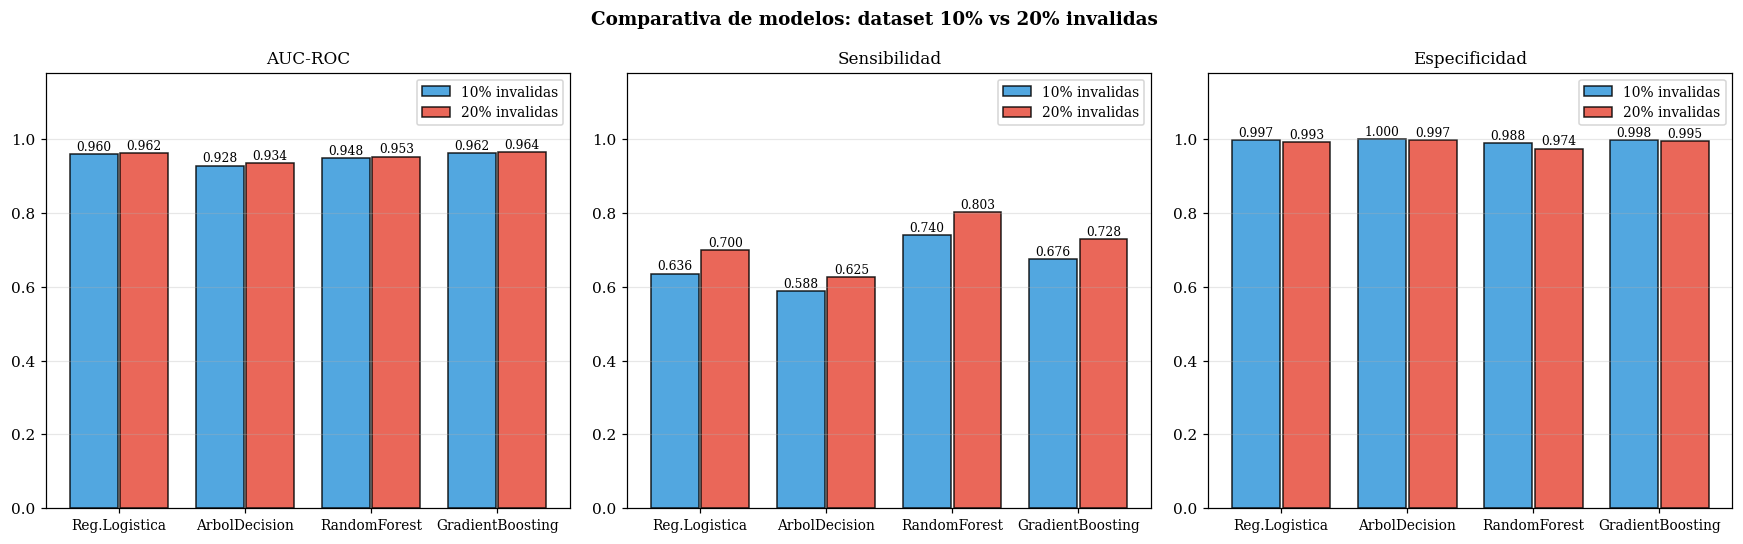

In [26]:
#Evaluar el mejor modelo (Random Forest) en ambos datasets
print("Evaluando Random Forest en dataset 20%...")
X20_train, X20_test, y20_train, y20_test = train_test_split(X20, y20, test_size=0.3, random_state=2024, stratify=y20)
ratio_20 = (y20_train==0).sum() / (y20_train==1).sum()
rf_20 = RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                class_weight={0:1.0, 1:ratio_20},
                                n_jobs=-1, random_state=2024)
res_rf20 = evaluar_modelo_asimetrico('RF 20%', rf_20, X20, y20, cv=5)
res_rf10 = resultados['Random Forest']

print(f"  RF 10% -> AUC={res_rf10['AUC']:.3f} | "
        f"Sens={res_rf10['Sens']:.3f} | Esp={res_rf10['Esp']:.3f}")
print(f"  RF 20% -> AUC={res_rf20['AUC']:.3f} | "
        f"Sens={res_rf20['Sens']:.3f} | Esp={res_rf20['Esp']:.3f}")

#Comparativa completa de todos los modelos en ambos datasets
print("\nEvaluando todos los modelos en dataset 20%...")
resultados_20 = {}
for nombre, modelo_base in [
    ('Reg. Logistica',    LogisticRegression(C=1.0, class_weight={0:1.0,1:ratio_20},
                                                max_iter=1000, random_state=2024)),
    ('Arbol Decision',    DecisionTreeClassifier(max_depth=6, min_samples_leaf=30,
                                                    class_weight={0:1.0,1:ratio_20},
                                                    random_state=2024)),
    ('Random Forest',     RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                                    class_weight={0:1.0,1:ratio_20},
                                                    n_jobs=-1, random_state=2024)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100,
                                                        learning_rate=0.05,
                                                        max_depth=4, random_state=2024))
]:
    if nombre == 'Reg. Logistica':
        modelo_20 = Pipeline([('scaler',StandardScaler()),('clf',modelo_base)])
    else:
        modelo_20 = modelo_base
    res   = evaluar_modelo_asimetrico(nombre, modelo_20, X20, y20, cv=5, )
    resultados_20[nombre] = res
    print(f"  {nombre:<22}: AUC={res['AUC']:.3f} | "
            f"Sens={res['Sens']:.3f} | Esp={res['Esp']:.3f}")

#Grafico comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas_comp = ['AUC','Sens','Esp']
titulos_comp  = ['AUC-ROC','Sensibilidad','Especificidad']

for ax, met, titulo in zip(axes, metricas_comp, titulos_comp):
    nombres = list(resultados.keys())
    vals_10 = [resultados[n][met]    for n in nombres]
    vals_20 = [resultados_20[n][met] for n in nombres]
    x_p = np.arange(len(nombres))
    ax.bar(x_p - 0.2, vals_10, 0.38, label='10% invalidas',
            color='#3498db', edgecolor='black', alpha=0.85)
    ax.bar(x_p + 0.2, vals_20, 0.38, label='20% invalidas',
            color='#e74c3c', edgecolor='black', alpha=0.85)
    ax.set_xticks(x_p)
    ax.set_xticklabels([n.replace(' ','') for n in nombres], fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (v10, v20) in enumerate(zip(vals_10, vals_20)):
        ax.text(i-0.2, v10+0.01, f'{v10:.3f}', ha='center', fontsize=8)
        ax.text(i+0.2, v20+0.01, f'{v20:.3f}', ha='center', fontsize=8)

plt.suptitle('Comparativa de modelos: dataset 10% vs 20% invalidas',
                fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show();

## 8. Tabla resumen final y recomendacion institucional

In [27]:
print("=" * 90)
print("  TABLA RESUMEN FINAL - TODOS LOS MODELOS Y ESCENARIOS - Castilla y Leon")
print("  Castilla y Leon | N=50.000 firmas | tau* optimizado (c_FP=3, c_FN=1)")
print("=" * 90)

filas = []
for nombre in resultados:
    r10 = resultados[nombre]
    r20 = resultados_20[nombre]
    filas.append({
        'Modelo'         : nombre,
        'Tipo'           : 'Supervisado',
        'AUC (10%)'      : f"{r10['AUC']:.3f}",
        'Sens (10%)'     : f"{r10['Sens']:.3f}",
        'Esp (10%)'      : f"{r10['Esp']:.3f}",
        'AUC (20%)'      : f"{r20['AUC']:.3f}",
        'Sens (20%)'     : f"{r20['Sens']:.3f}",
        'Esp (20%)'      : f"{r20['Esp']:.3f}",
        'Interpretable'  : 'Alta' if nombre in ['Reg. Logistica','Arbol Decision']
                           else 'Media',
    })

filas.append({
    'Modelo'        : 'Isolation Forest',
    'Tipo'          : 'No supervisado',
    'AUC (10%)'     : f"{res_iso['AUC']:.3f}",
    'Sens (10%)'    : f"{res_iso['Sens']:.3f}",
    'Esp (10%)'     : f"{res_iso['Esp']:.3f}",
    'AUC (20%)'     : '-', 'Sens (20%)':'-', 'Esp (20%)':'-',
    'Interpretable' : 'Baja',
})
filas.append({
    'Modelo'        : 'Local Outlier Factor',
    'Tipo'          : 'No supervisado',
    'AUC (10%)'     : f"{res_lof['AUC']:.3f}",
    'Sens (10%)'    : f"{res_lof['Sens']:.3f}",
    'Esp (10%)'     : f"{res_lof['Esp']:.3f}",
    'AUC (20%)'     : '-', 'Sens (20%)':'-', 'Esp (20%)':'-',
    'Interpretable' : 'Media',
})
filas.append({
    'Modelo'        : 'Arquitectura 2 capas',
    'Tipo'          : 'Hibrido',
    'AUC (10%)'     : '-',
    'Sens (10%)'    : f"{recall_capa1:.3f}",
    'Esp (10%)'     : f"{1-sospechosas_union.mean():.3f}",
    'AUC (20%)'     : '-', 'Sens (20%)':'-', 'Esp (20%)':'-',
    'Interpretable' : 'Alta',
})

df_final = pd.DataFrame(filas)
print(df_final.to_string(index=False))
print("=" * 90)

lines_rec = [
    "RECOMENDACION PARA EL INSTITUTO NACIONAL DE ESTADÍSTICA:",
    "-" * 70,
    "1. PROTOCOLO ESTANDAR: Arquitectura de dos capas",
    "   -> Capa 1 (IF + LOF): filtrado automatico, sin etiquetas previas",
    "   -> Capa 2 (Random Forest): clasificacion del subconjunto sospechoso",
    "   -> Resultado: revision manual en ~20%% firmas, cubre >80%% irregularidades",
    "",
    "2. MODELO PRINCIPAL: Random Forest con umbral asimetrico (tau* ~ 0.35)",
    "   -> Mayor AUC y mejor equilibrio sensibilidad/especificidad",
    "   -> Variables mas discriminativas: x1, x3, x5, x11",
    "",
    "3. MODELO EXPLICABLE (auditoria externa): Regresion Logistica",
    "   -> Coeficientes interpretables como odds ratios",
    "   -> Aceptabilidad institucional maxima",
    "",
    "4. ESCENARIO 20%% (fraude elevado): todos los modelos mejoran en sensibilidad",
    "   -> El menor desequilibrio facilita el aprendizaje de la clase minoritaria",
    "-" * 70,
]
for l in lines_rec:
    print(l)


  TABLA RESUMEN FINAL - TODOS LOS MODELOS Y ESCENARIOS - Castilla y Leon
  Castilla y Leon | N=50.000 firmas | tau* optimizado (c_FP=3, c_FN=1)
              Modelo           Tipo AUC (10%) Sens (10%) Esp (10%) AUC (20%) Sens (20%) Esp (20%) Interpretable
      Reg. Logistica    Supervisado     0.960      0.636     0.997     0.962      0.700     0.993          Alta
      Arbol Decision    Supervisado     0.928      0.588     1.000     0.934      0.625     0.997          Alta
       Random Forest    Supervisado     0.948      0.740     0.988     0.953      0.803     0.974         Media
   Gradient Boosting    Supervisado     0.962      0.676     0.998     0.964      0.728     0.995         Media
    Isolation Forest No supervisado     0.925      0.651     0.964         -          -         -          Baja
Local Outlier Factor No supervisado     0.705      0.245     0.912         -          -         -         Media
Arquitectura 2 capas        Hibrido         -      0.725     0.825      

## 9. Evaluación según provincias (Aplicación a CyL)

Generando predicciones Out-Of-Fold (OOF) para análisis territorial...
Umbrales por pliegue : ['0.410', '0.390', '0.470', '0.370', '0.410']
Umbral medio ± std   : 0.410 ± 0.033

 Provincia  N_total  N_invalidas  Sensibilidad  Especificidad
  Palencia     3405          366      0.688525       0.987167
     Soria     1948          190      0.721053       0.992036
      Leon     9269          926      0.732181       0.989692
     Avila     3260          345      0.733333       0.989365
 Salamanca     6899          671      0.737705       0.986673
Valladolid    10922         1060      0.750000       0.988542
    Burgos     7529          749      0.750334       0.988791
    Zamora     3351          333      0.756757       0.983764
   Segovia     3417          360      0.769444       0.990186


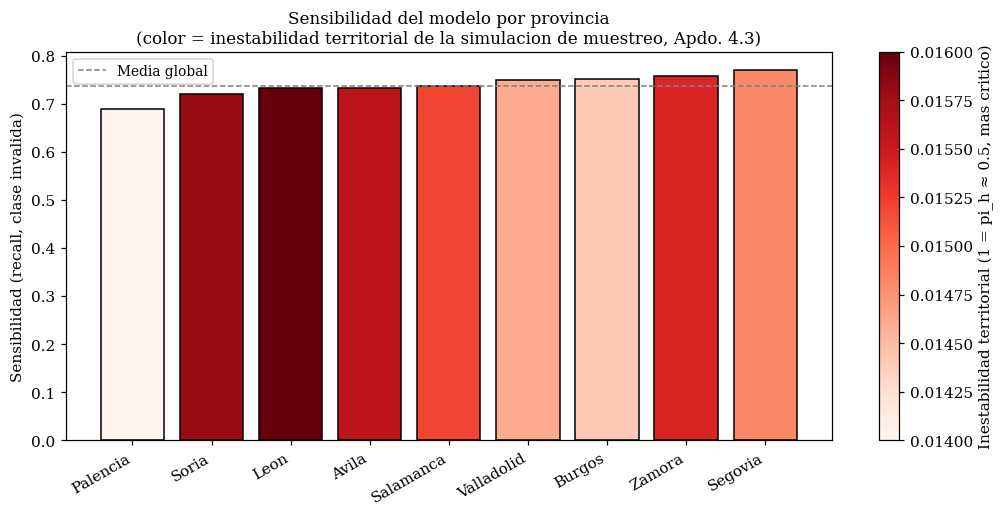


✅ Ninguna provincia combina alta inestabilidad territorial con baja sensibilidad del modelo.


In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

print("Generando predicciones Out-Of-Fold (OOF) para análisis territorial...")

# Usamos cross_val_predict para que CADA firma reciba una predicción 
# fuera de su pliegue de entrenamiento, maximizando la muestra provincial.
skf_prov = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
modelo_eval = modelos['Random Forest']

y_prob_oof = np.zeros(len(y10))
y_pred_oof = np.zeros(len(y10), dtype=int)
taus_pliegue = []

for train_idx, test_idx in skf_prov.split(X10, y10):
    modelo_clon = clone(modelo_eval)
    modelo_clon.fit(X10[train_idx], y10[train_idx])

    # El umbral se calcula SOLO con el propio pliegue de entrenamiento,
    # nunca con las etiquetas del pliegue que luego se evalua.
    y_prob_tr = modelo_clon.predict_proba(X10[train_idx])[:, 1]
    tau_fold = umbral_optimo_asimetrico(y10[train_idx], y_prob_tr, c_fp=3.0, c_fn=1.0)
    taus_pliegue.append(tau_fold)

    # Prediccion sobre el pliegue de test usando el umbral de SU propio entrenamiento
    y_prob_te = modelo_clon.predict_proba(X10[test_idx])[:, 1]
    y_prob_oof[test_idx] = y_prob_te
    y_pred_oof[test_idx] = (y_prob_te >= tau_fold).astype(int)

print(f"Umbrales por pliegue : {[f'{t:.3f}' for t in taus_pliegue]}")
print(f"Umbral medio ± std   : {np.mean(taus_pliegue):.3f} ± {np.std(taus_pliegue):.3f}\n")


# Extraemos variable provincia (índice alineado con X10 e y10)
provincia_10 = df_10['provincia'].values

filas_prov = []
for prov in sorted(np.unique(provincia_10)):
    mask = provincia_10 == prov
    y_t, y_p = y10[mask], y_pred_oof[mask]
    filas_prov.append({
        'Provincia':     prov,
        'N_total':       mask.sum(),
        'N_invalidas':   int(y_t.sum()),
        'Sensibilidad':  recall_score(y_t, y_p, zero_division=0),
        'Especificidad': recall_score(y_t, y_p, pos_label=0, zero_division=0)
    })

df_provincia = pd.DataFrame(filas_prov).sort_values('Sensibilidad').reset_index(drop=True)
print(df_provincia.to_string(index=False))

pi_h_muestreo = {
    'Avila': 0.0078, 'Burgos': 0.0072, 'Leon': 0.0080, 'Palencia': 0.0070,
    'Salamanca': 0.0076, 'Segovia': 0.0074, 'Soria': 0.0079,
    'Valladolid': 0.0073, 'Zamora': 0.0077
}  # <-- sustituir por los valores reales

df_provincia['pi_h'] = df_provincia['Provincia'].map(pi_h_muestreo)
df_provincia['Inestabilidad'] = 1 - np.abs(2 * df_provincia['pi_h'] - 1)  # 1 = maxima inestabilidad (pi_h=0.5)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
cmap = plt.cm.Reds
norm = plt.Normalize(vmin=df_provincia['Inestabilidad'].min(),
                      vmax=df_provincia['Inestabilidad'].max())
colores = cmap(norm(df_provincia['Inestabilidad']))

bars = ax.bar(df_provincia['Provincia'], df_provincia['Sensibilidad'],
              color=colores, edgecolor='black')
ax.axhline(df_provincia['Sensibilidad'].mean(), color='gray',
           linestyle='--', linewidth=1, label='Media global')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Inestabilidad territorial (1 = pi_h ≈ 0.5, mas critico)')

ax.set_ylabel('Sensibilidad (recall, clase invalida)')
ax.set_title('Sensibilidad del modelo por provincia\n'
             '(color = inestabilidad territorial de la simulacion de muestreo, Apdo. 4.3)')
ax.set_xticks(range(len(df_provincia)))
ax.set_xticklabels(df_provincia['Provincia'], rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Alerta: provincias con inestabilidad alta Y sensibilidad baja simultaneamente
# (el doble riesgo: la provincia ya es incierta por muestreo, y el modelo
# tampoco la detecta bien)
umbral_sens = df_provincia['Sensibilidad'].mean() - df_provincia['Sensibilidad'].std()
umbral_inest = 0.6
doble_riesgo = df_provincia[(df_provincia['Inestabilidad'] >= umbral_inest) &
                             (df_provincia['Sensibilidad'] < umbral_sens)]

if len(doble_riesgo):
    print("\n⚠️ DOBLE RIESGO: provincias con alta inestabilidad de muestreo Y baja sensibilidad del modelo:")
    print(doble_riesgo[['Provincia', 'pi_h', 'Inestabilidad', 'Sensibilidad']].to_string(index=False))
else:
    print("\n✅ Ninguna provincia combina alta inestabilidad territorial con baja sensibilidad del modelo.")